In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [12]:
!pip install dagshub mlflow wandb -q

import sys, math, time, warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import mlflow
import wandb
import dagshub
from kaggle_secrets import UserSecretsClient

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

dagshub.init(repo_owner='lshek22', repo_name='walmart-recruiting-store-sales-forecasting', mlflow=True)

secrets = UserSecretsClient()
wandb.login(key=secrets.get_secret("WANDB_API_KEY"))
print("MLflow URI:", mlflow.get_tracking_uri())
print("W&B ready.")

Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4
VRAM: 15.6 GB


Initialized MLflow to track repo "lshek22/walmart-recruiting-store-sales-forecasting"

Repository lshek22/walmart-recruiting-store-sales-forecasting initialized!

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


MLflow URI: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow
W&B ready.


In [13]:
DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

train    = pd.read_csv(f"{DATA_DIR}/train.csv.zip")
test     = pd.read_csv(f"{DATA_DIR}/test.csv.zip")
stores   = pd.read_csv(f"{DATA_DIR}/stores.csv")
features = pd.read_csv(f"{DATA_DIR}/features.csv.zip")

for df in [train, test, features]:
    df['Date'] = pd.to_datetime(df['Date'])

train = (train
         .merge(stores, on='Store', how='left')
         .merge(features.drop(columns=['IsHoliday']), on=['Store','Date'], how='left'))

test = (test
        .merge(stores, on='Store', how='left')
        .merge(features.drop(columns=['IsHoliday']), on=['Store','Date'], how='left'))

md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
train[md_cols] = train[md_cols].fillna(0)
test[md_cols]  = test[md_cols].fillna(0)

for col in ['CPI', 'Unemployment']:
    train[col] = train.groupby('Store')[col].transform(
        lambda x: x.fillna(method='ffill').fillna(method='bfill'))
    test[col] = test.groupby('Store')[col].transform(
        lambda x: x.fillna(method='ffill').fillna(method='bfill'))

train['Weekly_Sales'] = train['Weekly_Sales'].clip(lower=0)

train = train.sort_values(['Store','Dept','Date']).reset_index(drop=True)
test  = test.sort_values(['Store','Dept','Date']).reset_index(drop=True)

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Date range: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Unique series: {train.groupby(['Store','Dept']).ngroups}")

Train: (421570, 16)  |  Test: (115064, 15)
Date range: 2010-02-05 → 2012-10-26
Unique series: 3331


In [14]:
HOLIDAY_DATES = {
    '2010-02-12': 'super_bowl',  '2011-02-11': 'super_bowl',
    '2012-02-10': 'super_bowl',  '2013-02-08': 'super_bowl',
    '2010-09-10': 'labor_day',   '2011-09-09': 'labor_day',
    '2012-09-07': 'labor_day',   '2013-09-06': 'labor_day',
    '2010-11-26': 'thanksgiving', '2011-11-25': 'thanksgiving',
    '2012-11-23': 'thanksgiving', '2013-11-29': 'thanksgiving',
    '2010-12-31': 'christmas',   '2011-12-30': 'christmas',
    '2012-12-28': 'christmas',
}

def add_features(df):
    df = df.copy()

    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month']        = df['Date'].dt.month
    df['year']         = df['Date'].dt.year
    df['quarter']      = df['Date'].dt.quarter

    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52.18)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52.18)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    date_str = df['Date'].dt.strftime('%Y-%m-%d')
    holiday_name = date_str.map(HOLIDAY_DATES)
    df['IsHoliday']      = df['IsHoliday'].astype(int)
    df['is_super_bowl']  = (holiday_name == 'super_bowl').astype(int)
    df['is_labor_day']   = (holiday_name == 'labor_day').astype(int)
    df['is_thanksgiving']= (holiday_name == 'thanksgiving').astype(int)
    df['is_christmas']   = (holiday_name == 'christmas').astype(int)
    df['holiday_weight'] = df['IsHoliday'].map({1: 5, 0: 1})

    df['store_type_enc'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})

    df['total_markdown'] = df[md_cols].sum(axis=1)
    df['any_markdown']   = (df['total_markdown'] > 0).astype(int)

    df['weeks_to_christmas'] = (52 - df['week_of_year']).clip(lower=0)

    return df

train = add_features(train)
test  = add_features(test)

STATIC_FEATURES = [
    'store_type_enc', 
    'Size', 
    'Store',  
    'Dept', 
]

TIME_VARYING_KNOWN = [
    'week_of_year', 'month', 'year', 'quarter',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'weeks_to_christmas',
    'IsHoliday', 'is_super_bowl', 'is_labor_day',
    'is_thanksgiving', 'is_christmas',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'total_markdown', 'any_markdown',
]

print(f"Static features: {len(STATIC_FEATURES)}")
print(f"Time-varying known: {len(TIME_VARYING_KNOWN)}")

Static features: 4
Time-varying known: 20


In [15]:
SPLIT_DATE = pd.Timestamp('2012-07-01')

train_df = train[train['Date'] <  SPLIT_DATE].copy()
val_df   = train[train['Date'] >= SPLIT_DATE].copy()

print(f"Train: {train_df['Date'].min().date()} → {train_df['Date'].max().date()}  ({len(train_df):,} rows)")
print(f"Val: {val_df['Date'].min().date()}   → {val_df['Date'].max().date()}   ({len(val_df):,} rows)")

covariate_scaler = StandardScaler()
covariate_scaler.fit(train_df[TIME_VARYING_KNOWN].fillna(0))

def scale_covariates(df):
    df = df.copy()
    df[TIME_VARYING_KNOWN] = covariate_scaler.transform(df[TIME_VARYING_KNOWN].fillna(0))
    return df

train_scaled = scale_covariates(train_df)
val_scaled   = scale_covariates(val_df)
test_scaled  = scale_covariates(test)

mlflow.set_experiment("TFT_Training")
with mlflow.start_run(run_name="TFT_Cleaning"):
    mlflow.log_params({
        "split_date":           str(SPLIT_DATE.date()),
        "markdown_imputation":  "fill_zero",
        "covariate_scaling":    "StandardScaler_fit_on_train",
        "target_scaling":       "per_series_mean_std",
        "n_static_features":    len(STATIC_FEATURES),
        "n_time_varying_known": len(TIME_VARYING_KNOWN),
        "train_rows":           len(train_df),
        "val_rows":             len(val_df),
    })
    mlflow.log_text(
        f"Train: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}\n"
        f"Val: {val_df['Date'].min().date()} to {val_df['Date'].max().date()}\n"
        f"Series: {train_df.groupby(['Store','Dept']).ngroups}\n",
        "data_summary.txt"
    )
    print("Cleaning run logged")

Train: 2010-02-05 → 2012-06-29  (371,242 rows)
Val: 2012-07-06   → 2012-10-26   (50,328 rows)
Cleaning run logged
🏃 View run TFT_Cleaning at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/e70abac1a4c64890a6f6e08483774b11
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4


In [16]:
class GatedLinearUnit(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, input_dim * 2)

    def forward(self, x):
        x = self.fc(x)
        value, gate = x.chunk(2, dim=-1)
        return value * torch.sigmoid(gate)


class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1, context_dim=None):
        super().__init__()
        self.input_dim   = input_dim
        self.output_dim  = output_dim

        self.skip_proj = (nn.Linear(input_dim, output_dim)
                         if input_dim != output_dim else nn.Identity())

        self.context_proj = (nn.Linear(context_dim, hidden_dim)
                            if context_dim is not None else None)

        self.fc1     = nn.Linear(input_dim, hidden_dim)
        self.fc2     = nn.Linear(hidden_dim, output_dim)
        self.glu     = GatedLinearUnit(output_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(output_dim)

    def forward(self, x, context=None):
        residual = self.skip_proj(x)

        h = F.elu(self.fc1(x))

        if context is not None and self.context_proj is not None:
            h = h + self.context_proj(context)

        h = self.dropout(self.fc2(h))
        h = self.glu(h)

        return self.norm(h + residual)


class VariableSelectionNetwork(nn.Module):
    def __init__(self, n_vars, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.n_vars    = n_vars
        self.input_dim = input_dim

        self.var_grns = nn.ModuleList([
            GatedResidualNetwork(input_dim, hidden_dim, hidden_dim, dropout)
            for _ in range(n_vars)
        ])

        self.softmax_grn = GatedResidualNetwork(
            input_dim * n_vars, hidden_dim, n_vars, dropout
        )

    def forward(self, x):
        if x.dim() == 2:
            var_inputs = x.chunk(self.n_vars, dim=-1)
            processed  = torch.stack([grn(v) for grn, v in
                                      zip(self.var_grns, var_inputs)], dim=1)
            weights = F.softmax(self.softmax_grn(x), dim=-1)
            selected = (processed * weights.unsqueeze(-1)).sum(dim=1)
            context  = selected

        else:
            B, T, _ = x.shape
            var_inputs = x.chunk(self.n_vars, dim=-1)
            processed  = torch.stack([grn(v) for grn, v in
                                      zip(self.var_grns, var_inputs)], dim=2)
            weights = F.softmax(self.softmax_grn(x), dim=-1)
            selected = (processed * weights.unsqueeze(-1)).sum(dim=2)
            context  = selected.mean(dim=1)

        return selected, weights, context

In [17]:
class TemporalFusionTransformer(nn.Module):
    def __init__(
        self,
        n_static:           int, 
        n_time_varying:     int, 
        seq_len:            int, 
        pred_len:           int, 
        d_model:            int = 64, 
        n_heads:            int = 4,  
        n_lstm_layers:      int = 2, 
        dropout:            float = 0.1,
    ):
        super().__init__()

        self.seq_len   = seq_len
        self.pred_len  = pred_len
        self.d_model   = d_model
        self.n_static  = n_static
        self.n_tv      = n_time_varying

        self.static_embedding = nn.Linear(1, d_model)
        self.static_vsn       = VariableSelectionNetwork(
            n_vars=n_static, input_dim=d_model, hidden_dim=d_model, dropout=dropout
        )
        self.static_context_grn = GatedResidualNetwork(
            d_model, d_model, d_model, dropout
        )

        self.target_embedding  = nn.Linear(1, d_model)
        self.tv_embedding      = nn.Linear(1, d_model)
        self.temporal_vsn      = VariableSelectionNetwork(
            n_vars=n_time_varying + 1,  
            input_dim=d_model,
            hidden_dim=d_model,
            dropout=dropout
        )

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=n_lstm_layers,
            batch_first=True,
            dropout=dropout if n_lstm_layers > 1 else 0,
        )
        self.lstm_gate = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Sigmoid()
        )
        self.lstm_norm = nn.LayerNorm(d_model)

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.attention_gate = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Sigmoid()
        )
        self.attention_norm = nn.LayerNorm(d_model)

        self.decoder_grn = GatedResidualNetwork(
            d_model, d_model, d_model, dropout,
            context_dim=d_model
        )

        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, pred_len),
        )

    def forward(self, target_seq, static_feats, time_varying_feats):
        B, T = target_seq.shape
        static_embedded = torch.stack([
            self.static_embedding(static_feats[:, i:i+1])
            for i in range(self.n_static)
        ], dim=1) 

        static_flat = static_embedded.reshape(B, -1)
        static_selected, static_weights, static_context = self.static_vsn(static_flat)
        static_ctx = self.static_context_grn(static_context) 

 
        target_emb = self.target_embedding(target_seq.unsqueeze(-1))

        tv_embedded = torch.stack([
            self.tv_embedding(time_varying_feats[:, :, i:i+1])
            for i in range(self.n_tv)
        ], dim=2)

     
        temporal_input = torch.cat([
            target_emb,
            tv_embedded.reshape(B, T, -1)
        ], dim=-1)

        temporal_selected, vsn_weights, _ = self.temporal_vsn(temporal_input)

        static_expanded = static_ctx.unsqueeze(1).expand(-1, T, -1)
        temporal_with_ctx = temporal_selected + static_expanded

        lstm_out, _ = self.lstm(temporal_with_ctx)

        gate = self.lstm_gate(temporal_with_ctx)
        lstm_out = self.lstm_norm(temporal_with_ctx + gate * lstm_out)

        attn_out, attn_weights = self.attention(lstm_out, lstm_out, lstm_out)

        gate2 = self.attention_gate(lstm_out)
        attn_out = self.attention_norm(lstm_out + gate2 * attn_out)

        decoded = self.decoder_grn(attn_out, context=static_ctx.unsqueeze(1).expand(-1, T, -1))

        
        pooled = decoded.mean(dim=1)

        output = self.output_proj(pooled) 

        return output, attn_weights, vsn_weights


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [18]:
class WalmartTFTDataset(Dataset):
    def __init__(self, df, seq_len=52, pred_len=12,
                 static_cols=STATIC_FEATURES,
                 tv_cols=TIME_VARYING_KNOWN,
                 is_train=True,
                 min_target_date=None):

        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.static_cols = static_cols
        self.tv_cols    = tv_cols

        self.sequences = []
        self.targets   = []
        self.statics   = []
        self.tv_feats  = []
        self.holidays  = [] 


        self.series_stats = {}

        skipped = 0
        for (store, dept), grp in df.groupby(['Store','Dept']):
            grp = grp.sort_values('Date').reset_index(drop=True)
            sales = grp['Weekly_Sales'].values.astype(np.float32)
            dates = grp['Date'].values  
            if len(sales) < seq_len + pred_len:
                skipped += 1
                continue


            mu  = sales.mean()
            std = sales.std() + 1e-8
            self.series_stats[(store, dept)] = (mu, std)
            sales_norm = (sales - mu) / std

            static_vec = grp[static_cols].iloc[0].values.astype(np.float32)

            tv_matrix = grp[tv_cols].values.astype(np.float32)

            holiday_vec = grp['IsHoliday'].values.astype(np.float32)

            for i in range(len(sales) - seq_len - pred_len + 1):
                target_start_date = dates[i + seq_len]
                if min_target_date is not None and target_start_date < min_target_date:
                    continue 
                
                self.sequences.append(sales_norm[i : i + seq_len])
                self.targets.append(sales[i + seq_len : i + seq_len + pred_len])
                self.statics.append(static_vec)
                self.tv_feats.append(tv_matrix[i : i + seq_len])
                self.holidays.append(holiday_vec[i + seq_len : i + seq_len + pred_len])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets   = np.array(self.targets,   dtype=np.float32)
        self.statics   = np.array(self.statics,   dtype=np.float32)
        self.tv_feats  = np.array(self.tv_feats,  dtype=np.float32)
        self.holidays  = np.array(self.holidays,  dtype=np.float32)

        print(f"Dataset built: {len(self.sequences):,} windows  (skipped {skipped} short series)")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.sequences[idx]),
            torch.from_numpy(self.targets[idx]),
            torch.from_numpy(self.statics[idx]),
            torch.from_numpy(self.tv_feats[idx]),
            torch.from_numpy(self.holidays[idx]),
        )


def wmae_torch(y_true, y_pred, holiday_weights):
    w = np.where(holiday_weights > 0, 5.0, 1.0)
    return float(np.sum(w * np.abs(y_true - y_pred)) / np.sum(w))

In [19]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss = 0.0
    n_batches  = 0

    for seq, tgt, static, tv, _ in loader:
        seq    = seq.to(device)
        tgt    = tgt.to(device)
        static = static.to(device)
        tv     = tv.to(device)

        optimizer.zero_grad()
        pred, _, _ = model(seq, static, tv)

        loss = criterion(pred, tgt)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    all_preds, all_tgts, all_hols = [], [], []

    for seq, tgt, static, tv, hol in loader:
        seq    = seq.to(device)
        static = static.to(device)
        tv     = tv.to(device)

        pred, _, _ = model(seq, static, tv)
        all_preds.append(pred.cpu().numpy())
        all_tgts.append(tgt.numpy())
        all_hols.append(hol.numpy())

    preds = np.concatenate(all_preds).flatten()
    tgts  = np.concatenate(all_tgts).flatten()
    hols  = np.concatenate(all_hols).flatten()

    preds = np.clip(preds, 0, None)
    return wmae_torch(tgts, preds, hols), preds, tgts


def run_training(model, train_loader, val_loader, config, run_name):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config.get('weight_decay', 1e-4)
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config['epochs'],
        eta_min=config['lr'] * 0.01
    )

    criterion = nn.L1Loss()

    wandb.init(
        project="walmart-forecasting",
        name=run_name,
        config=config,
        reinit=True
    )

    best_wmae   = float('inf')
    best_state  = None
    patience_ct = 0

    print(f"\n{'='*55}")
    print(f"{run_name}")
    print(f"Params: {count_params(model):,}")
    print(f"{'='*55}")

    for epoch in range(1, config['epochs'] + 1):
        t0 = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_wmae, _, _ = eval_epoch(model, val_loader)
        scheduler.step()

        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]['lr']

        wandb.log({
            'epoch':      epoch,
            'train_loss': train_loss,
            'val_wmae':   val_wmae,
            'lr':         lr_now,
        })

        if val_wmae < best_wmae:
            best_wmae  = val_wmae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ct = 0
            marker = 'best'
        else:
            patience_ct += 1
            marker = ''

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{config['epochs']}  "
                  f"loss={train_loss:.4f}  val_wmae={val_wmae:,.1f}  "
                  f"lr={lr_now:.2e}  ({elapsed:.1f}s){marker}")

        if patience_ct >= config.get('patience', 15):
            print(f"\nEarly stopping at epoch {epoch} (patience={config['patience']})")
            break

    model.load_state_dict(best_state)
    wandb.finish()

    return best_wmae, model

In [20]:
print("Building datasets")
train_dataset = WalmartTFTDataset(train_scaled, seq_len=52, pred_len=12)

full_for_val = pd.concat([train_scaled, val_scaled]).sort_values(['Store','Dept','Date'])
val_dataset  = WalmartTFTDataset(full_for_val, seq_len=52, pred_len=12,
                                  min_target_date=SPLIT_DATE)

assert len(val_dataset) > 0, "Val dataset is empty — check seq_len/pred_len vs. date split"

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}. Val batches: {len(val_loader)}")

CONFIG_BASELINE = {
    'd_model':      32,
    'n_heads':      2,
    'n_lstm_layers':1,
    'dropout':      0.1,
    'lr':           1e-3,
    'weight_decay': 1e-4,
    'epochs':       30,
    'patience':     10,
    'batch_size':   BATCH_SIZE,
    'seq_len':      52,
    'pred_len':     12,
    'note':         'baseline — smallest config to establish floor WMAE',
}

model_baseline = TemporalFusionTransformer(
    n_static       = len(STATIC_FEATURES),
    n_time_varying = len(TIME_VARYING_KNOWN),
    seq_len        = CONFIG_BASELINE['seq_len'],
    pred_len       = CONFIG_BASELINE['pred_len'],
    d_model        = CONFIG_BASELINE['d_model'],
    n_heads        = CONFIG_BASELINE['n_heads'],
    n_lstm_layers  = CONFIG_BASELINE['n_lstm_layers'],
    dropout        = CONFIG_BASELINE['dropout'],
).to(device)

print(f"Baseline model params: {count_params(model_baseline):,}")

baseline_wmae, model_baseline = run_training(
    model_baseline, train_loader, val_loader, CONFIG_BASELINE, "TFT_Baseline"
)

with mlflow.start_run(run_name="TFT_Baseline"):
    mlflow.log_params(CONFIG_BASELINE)
    mlflow.log_metric("val_wmae", baseline_wmae)
    mlflow.log_metric("n_params", count_params(model_baseline))
    print(f"\nBaseline val WMAE: {baseline_wmae:,.2f}")

Building datasets
Dataset built: 179,098 windows  (skipped 367 short series)
Dataset built: 17,042 windows  (skipped 364 short series)
Train batches: 700. Val batches: 67
Baseline model params: 174,820



TFT_Baseline
Params: 174,820
Epoch   1/30  loss=16482.1955  val_wmae=16,032.7  lr=9.97e-04  (35.5s)best
Epoch   5/30  loss=12625.1719  val_wmae=12,255.2  lr=9.34e-04  (35.4s)best
Epoch  10/30  loss=10196.8149  val_wmae=9,849.2  lr=7.53e-04  (35.3s)best
Epoch  15/30  loss=7457.9205  val_wmae=7,575.9  lr=5.05e-04  (35.1s)best
Epoch  20/30  loss=5764.6531  val_wmae=6,080.7  lr=2.58e-04  (35.6s)best
Epoch  25/30  loss=5187.6010  val_wmae=5,814.0  lr=7.63e-05  (36.2s)
Epoch  30/30  loss=5022.1179  val_wmae=5,707.9  lr=1.00e-05  (34.7s)


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▆▆▅▅▅▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,1e-05
train_loss,5022.11795
val_wmae,5707.94323



Baseline val WMAE: 5,699.57
🏃 View run TFT_Baseline at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/cf148decca4645fba07dc6c0ebe2d72a
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4


In [21]:
CONFIG_MEDIUM = {
    **CONFIG_BASELINE,
    'd_model':       64,
    'n_heads':       4,
    'n_lstm_layers': 2,
    'dropout':       0.15,
    'lr':            5e-4,
    'epochs':        50,
    'patience':      12,
    'note':          'medium — double d_model and 2 LSTM layers',
}

model_medium = TemporalFusionTransformer(
    n_static       = len(STATIC_FEATURES),
    n_time_varying = len(TIME_VARYING_KNOWN),
    seq_len        = CONFIG_MEDIUM['seq_len'],
    pred_len       = CONFIG_MEDIUM['pred_len'],
    d_model        = CONFIG_MEDIUM['d_model'],
    n_heads        = CONFIG_MEDIUM['n_heads'],
    n_lstm_layers  = CONFIG_MEDIUM['n_lstm_layers'],
    dropout        = CONFIG_MEDIUM['dropout'],
).to(device)

print(f"Medium model params: {count_params(model_medium):,}")

medium_wmae, model_medium = run_training(
    model_medium, train_loader, val_loader, CONFIG_MEDIUM, "TFT_Medium"
)

with mlflow.start_run(run_name="TFT_Medium"):
    mlflow.log_params(CONFIG_MEDIUM)
    mlflow.log_metric("val_wmae", medium_wmae)
    mlflow.log_metric("n_params", count_params(model_medium))
    print(f"Medium val WMAE: {medium_wmae:,.2f}")
    print(f"Improvement over baseline: {baseline_wmae - medium_wmae:,.2f}")

Medium model params: 685,972



TFT_Medium
Params: 685,972
Epoch   1/50  loss=16540.9070  val_wmae=16,237.6  lr=5.00e-04  (48.1s)best
Epoch   5/50  loss=12996.8549  val_wmae=12,535.0  lr=4.88e-04  (47.5s)best
Epoch  10/50  loss=10228.8224  val_wmae=10,134.8  lr=4.53e-04  (47.6s)best
Epoch  15/50  loss=7187.8095  val_wmae=7,506.7  lr=3.98e-04  (47.6s)best
Epoch  20/50  loss=5195.4465  val_wmae=5,924.4  lr=3.29e-04  (47.7s)best
Epoch  25/50  loss=4249.6088  val_wmae=5,464.6  lr=2.52e-04  (47.6s)best
Epoch  30/50  loss=3805.8714  val_wmae=5,526.3  lr=1.76e-04  (48.8s)
Epoch  35/50  loss=3570.2919  val_wmae=5,354.2  lr=1.07e-04  (47.5s)
Epoch  40/50  loss=3413.9818  val_wmae=5,271.5  lr=5.23e-05  (47.3s)
Epoch  45/50  loss=3334.7756  val_wmae=5,274.0  lr=1.71e-05  (47.2s)

Early stopping at epoch 45 (patience=12)


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,████████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
train_loss,██▇▇▆▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,45
lr,2e-05
train_loss,3334.77558
val_wmae,5273.99415


Medium val WMAE: 5,214.97
Improvement over baseline: 484.60
🏃 View run TFT_Medium at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/eb11034802c64e5f819d4fc5f694f075
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4


In [22]:
print("Building datasets with seq_len=104")
train_104 = WalmartTFTDataset(train_scaled, seq_len=104, pred_len=12)

full_for_val_104 = pd.concat([train_scaled, val_scaled]).sort_values(['Store','Dept','Date'])
val_104 = WalmartTFTDataset(full_for_val_104, seq_len=104, pred_len=12,
                             min_target_date=SPLIT_DATE)

assert len(val_104) > 0, "Val (104) dataset is empty — check seq_len/pred_len vs. date split"

loader_train_104 = DataLoader(train_104, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)
loader_val_104   = DataLoader(val_104,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

CONFIG_LONG = {
    **CONFIG_MEDIUM,
    'seq_len':  104,
    'patience': 12,
    'note':     'long lookback — 104 weeks (2 years) of history',
}

model_long = TemporalFusionTransformer(
    n_static       = len(STATIC_FEATURES),
    n_time_varying = len(TIME_VARYING_KNOWN),
    seq_len        = CONFIG_LONG['seq_len'],
    pred_len       = CONFIG_LONG['pred_len'],
    d_model        = CONFIG_LONG['d_model'],
    n_heads        = CONFIG_LONG['n_heads'],
    n_lstm_layers  = CONFIG_LONG['n_lstm_layers'],
    dropout        = CONFIG_LONG['dropout'],
).to(device)

long_wmae, model_long = run_training(
    model_long, loader_train_104, loader_val_104, CONFIG_LONG, "TFT_LongLookback"
)

with mlflow.start_run(run_name="TFT_LongLookback"):
    mlflow.log_params(CONFIG_LONG)
    mlflow.log_metric("val_wmae", long_wmae)
    print(f"Long lookback val WMAE: {long_wmae:,.2f}")

Building datasets with seq_len=104
Dataset built: 29,963 windows  (skipped 560 short series)
Dataset built: 16,698 windows  (skipped 504 short series)



TFT_LongLookback
Params: 685,972
Epoch   1/50  loss=17172.7499  val_wmae=16,796.7  lr=5.00e-04  (18.9s)best
Epoch   5/50  loss=17065.3247  val_wmae=16,658.2  lr=4.88e-04  (17.8s)best
Epoch  10/50  loss=16641.9152  val_wmae=16,185.1  lr=4.53e-04  (18.0s)best
Epoch  15/50  loss=15858.1486  val_wmae=15,456.2  lr=3.98e-04  (18.0s)best
Epoch  20/50  loss=15026.8022  val_wmae=14,705.1  lr=3.29e-04  (18.0s)best
Epoch  25/50  loss=14364.0416  val_wmae=14,153.7  lr=2.52e-04  (18.0s)best
Epoch  30/50  loss=14036.1154  val_wmae=13,781.8  lr=1.76e-04  (18.0s)best
Epoch  35/50  loss=13680.3792  val_wmae=13,470.8  lr=1.07e-04  (18.0s)best
Epoch  40/50  loss=13579.0058  val_wmae=13,362.3  lr=5.23e-05  (17.9s)best
Epoch  45/50  loss=13524.7287  val_wmae=13,340.4  lr=1.71e-05  (18.1s)best
Epoch  50/50  loss=13590.6406  val_wmae=13,322.2  lr=5.00e-06  (18.0s)


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_loss,█████▇▇▇▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█████▇▇▇▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
lr,1e-05
train_loss,13590.64057
val_wmae,13322.15571


Long lookback val WMAE: 13,322.10
🏃 View run TFT_LongLookback at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/899f381971d54279a81dea1e78005fa5
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4


In [23]:
DROPOUT_CONFIGS = {
    'no_dropout':     {'dropout': 0.0,  'weight_decay': 0},
    'light_dropout':  {'dropout': 0.1,  'weight_decay': 1e-4},
    'medium_dropout': {'dropout': 0.2,  'weight_decay': 1e-3},
    'heavy_dropout':  {'dropout': 0.3,  'weight_decay': 1e-3},
}

dropout_results = {}

for name, reg_cfg in DROPOUT_CONFIGS.items():
    config = {
        **CONFIG_MEDIUM,
        **reg_cfg,
        'seq_len': 52,
        'epochs':  40,
        'note':    f'dropout={reg_cfg["dropout"]} wd={reg_cfg["weight_decay"]}',
    }

    m = TemporalFusionTransformer(
        n_static=len(STATIC_FEATURES), n_time_varying=len(TIME_VARYING_KNOWN),
        seq_len=52, pred_len=12,
        d_model=64, n_heads=4, n_lstm_layers=2,
        dropout=reg_cfg['dropout'],
    ).to(device)

    score, _ = run_training(m, train_loader, val_loader, config, f"TFT_Reg_{name}")

    dropout_results[name] = score
    with mlflow.start_run(run_name=f"TFT_Reg_{name}"):
        mlflow.log_params(config)
        mlflow.log_metric("val_wmae", score)
    print(f"{name}: {score:,.2f}")

best_dropout_cfg = min(dropout_results, key=dropout_results.get)
print(f"\nBest dropout config: {best_dropout_cfg} → {dropout_results[best_dropout_cfg]:,.2f}")


TFT_Reg_no_dropout
Params: 685,972
Epoch   1/40  loss=16515.9937  val_wmae=16,159.8  lr=4.99e-04  (46.1s)best
Epoch   5/40  loss=13121.0010  val_wmae=13,055.1  lr=4.81e-04  (45.9s)best
Epoch  10/40  loss=10251.9196  val_wmae=10,187.7  lr=4.28e-04  (45.9s)best
Epoch  15/40  loss=6658.7977  val_wmae=7,294.7  lr=3.47e-04  (45.7s)best
Epoch  20/40  loss=4458.1687  val_wmae=6,014.5  lr=2.52e-04  (45.7s)best
Epoch  25/40  loss=3348.4595  val_wmae=5,351.9  lr=1.58e-04  (45.6s)
Epoch  30/40  loss=2902.2938  val_wmae=5,126.9  lr=7.75e-05  (46.2s)
Epoch  35/40  loss=2711.6109  val_wmae=5,105.7  lr=2.38e-05  (45.6s)
Epoch  40/40  loss=2650.7731  val_wmae=5,065.6  lr=5.00e-06  (46.3s)


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_loss,██▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,1e-05
train_loss,2650.77308
val_wmae,5065.5974


🏃 View run TFT_Reg_no_dropout at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/6f9396b9272a48e9917cadc104852ad2
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
no_dropout: 5,046.21



TFT_Reg_light_dropout
Params: 685,972
Epoch   1/40  loss=16549.1748  val_wmae=16,261.8  lr=4.99e-04  (47.6s)best
Epoch   5/40  loss=13255.8697  val_wmae=12,917.8  lr=4.81e-04  (47.7s)best
Epoch  10/40  loss=11337.6307  val_wmae=11,115.5  lr=4.28e-04  (47.6s)best
Epoch  15/40  loss=8710.3206  val_wmae=8,671.2  lr=3.47e-04  (47.6s)best
Epoch  20/40  loss=6358.6676  val_wmae=6,516.7  lr=2.52e-04  (47.7s)best
Epoch  25/40  loss=5039.9379  val_wmae=5,447.1  lr=1.58e-04  (47.3s)best
Epoch  30/40  loss=4474.7207  val_wmae=5,062.3  lr=7.75e-05  (47.2s)best
Epoch  35/40  loss=4202.0028  val_wmae=4,907.3  lr=2.38e-05  (47.1s)
Epoch  40/40  loss=4113.2923  val_wmae=4,858.5  lr=5.00e-06  (47.1s)


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_loss,██▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,██▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,1e-05
train_loss,4113.29231
val_wmae,4858.50138


...

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_loss,██▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,██▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,1e-05
train_loss,3785.1267
val_wmae,4098.08776


🏃 View run TFT_Reg_medium_dropout at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/ac49324f1a0a4c1e940ff9af808379bc
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
medium_dropout: 4,097.66



TFT_Reg_heavy_dropout
Params: 685,972
Epoch   1/40  loss=16540.4590  val_wmae=16,227.7  lr=4.99e-04  (47.6s)best
Epoch   5/40  loss=13355.8452  val_wmae=12,920.6  lr=4.81e-04  (47.4s)best
Epoch  10/40  loss=10654.2653  val_wmae=10,428.4  lr=4.28e-04  (47.4s)best
Epoch  15/40  loss=7684.1698  val_wmae=7,749.8  lr=3.47e-04  (48.4s)best
Epoch  20/40  loss=5591.7593  val_wmae=6,069.9  lr=2.52e-04  (50.5s)best
Epoch  25/40  loss=4694.7921  val_wmae=5,643.2  lr=1.58e-04  (47.1s)best
Epoch  30/40  loss=4327.9879  val_wmae=5,583.5  lr=7.75e-05  (47.2s)
Epoch  35/40  loss=4162.7189  val_wmae=5,353.5  lr=2.38e-05  (47.5s)
Epoch  40/40  loss=4104.3791  val_wmae=5,292.1  lr=5.00e-06  (47.4s)


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_loss,██▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,1e-05
train_loss,4104.37907
val_wmae,5292.13166


🏃 View run TFT_Reg_heavy_dropout at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/d17464086e5d4e44a2ccc89754936155
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
heavy_dropout: 5,287.42

Best dropout config: medium_dropout → 4,097.66


In [24]:
def run_with_scheduler(scheduler_name, config, run_name):
    m = TemporalFusionTransformer(
        n_static=len(STATIC_FEATURES), n_time_varying=len(TIME_VARYING_KNOWN),
        seq_len=52, pred_len=12, d_model=64, n_heads=4, n_lstm_layers=2,
        dropout=DROPOUT_CONFIGS[best_dropout_cfg]['dropout'],
    ).to(device)

    optimizer = torch.optim.AdamW(m.parameters(), lr=config['lr'], weight_decay=1e-4)
    criterion = nn.L1Loss()

    if scheduler_name == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epochs'], eta_min=config['lr']*0.01)
    elif scheduler_name == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.5)
    elif scheduler_name == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=5, factor=0.5, mode='min')
    else:
        scheduler = None

    wandb.init(entity="ml-final-projekt", project="walmart-forecasting", name=run_name,
               config={**config, 'scheduler': scheduler_name}, reinit=True)

    best_wmae, best_state = float('inf'), None

    for epoch in range(1, config['epochs']+1):
        loss = train_epoch(m, train_loader, optimizer, criterion)
        val_score, _, _ = eval_epoch(m, val_loader)

        if scheduler_name == 'plateau':
            scheduler.step(val_score)
        elif scheduler is not None:
            scheduler.step()

        wandb.log({'epoch': epoch, 'train_loss': loss, 'val_wmae': val_score})

        if val_score < best_wmae:
            best_wmae = val_score
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_state)
    wandb.finish()
    return best_wmae, m
    
scheduler_results = {}
scheduler_models  = {}

for sched_name in ['cosine', 'step', 'plateau']:
    cfg = {**CONFIG_MEDIUM, 'seq_len': 52, 'epochs': 40,
           'note': f'scheduler={sched_name}'}
    score, trained_m = run_with_scheduler(
        sched_name, cfg, f"TFT_Scheduler_{sched_name}"
    )
    scheduler_results[sched_name] = score
    scheduler_models[sched_name]  = trained_m

    with mlflow.start_run(run_name=f"TFT_Scheduler_{sched_name}"):
        mlflow.log_params({**cfg, 'scheduler': sched_name})
        mlflow.log_metric("val_wmae", score)
    print(f"  {sched_name}: {score:,.2f}")

best_sched = min(scheduler_results, key=scheduler_results.get)
print(f"\nBest scheduler: {best_sched}")

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,██▇▆▆▆▆▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
train_loss,3898.78328
val_wmae,6776.30764


🏃 View run TFT_Scheduler_cosine at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/430c1d1c575849808b71e74ed03387ba
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
  cosine: 6,716.21


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,██▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
train_loss,4252.07671
val_wmae,5863.69661


🏃 View run TFT_Scheduler_step at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/977c2fbe82424187aa576e72da69dfbb
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
  step: 5,767.01


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,██▇▇▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,██▇▆▆▆▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
train_loss,3204.01696
val_wmae,4028.45214


🏃 View run TFT_Scheduler_plateau at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4/runs/e40ef358e4474859beb66f96cbb275c7
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/4
  plateau: 3,966.11

Best scheduler: plateau


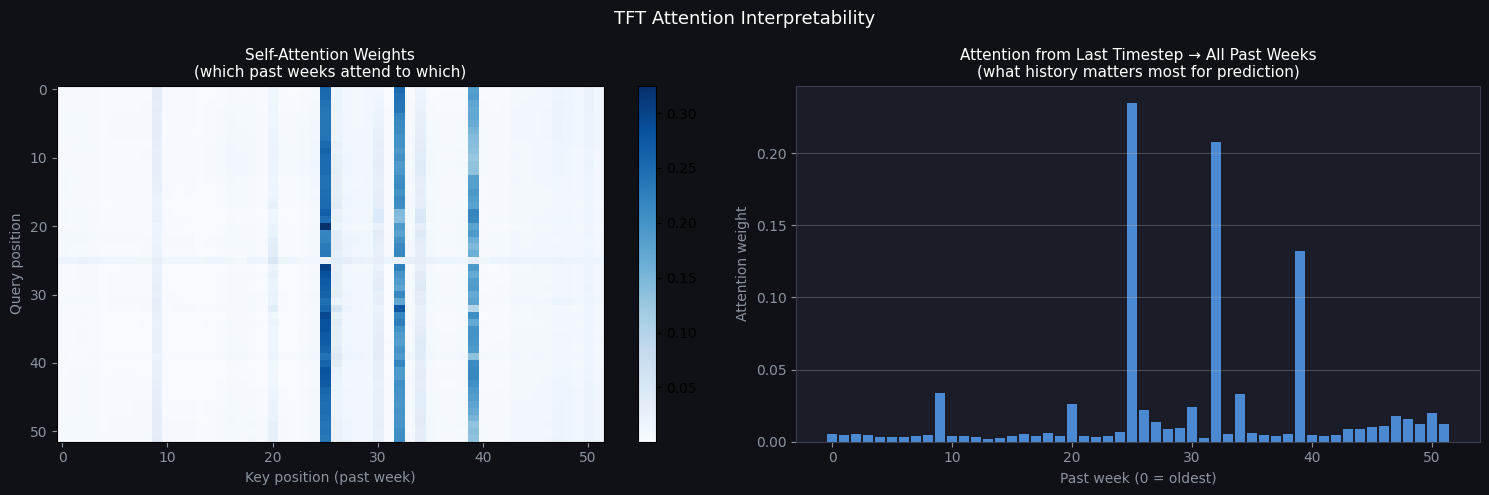

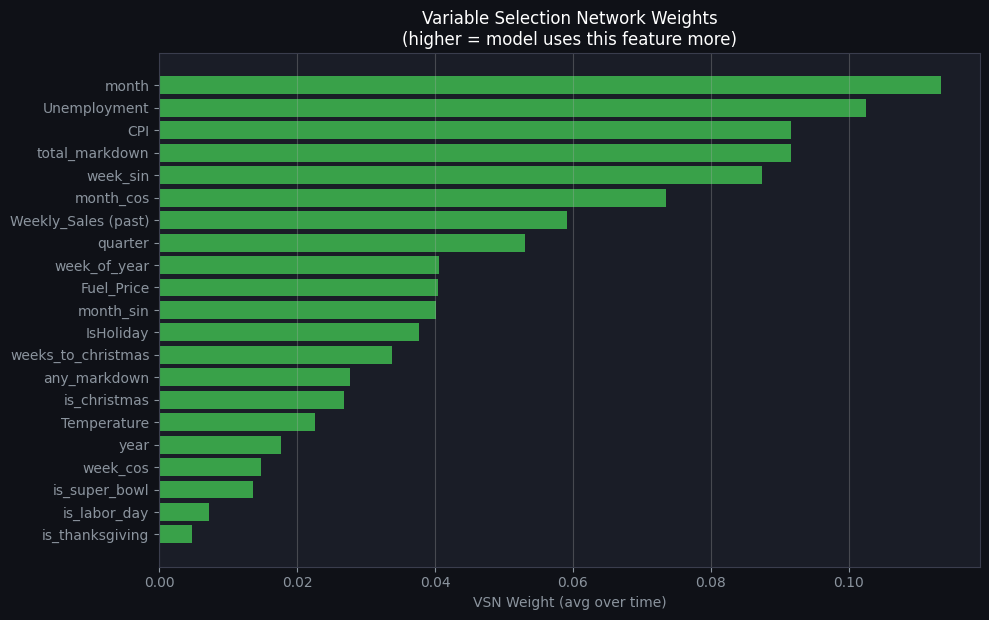

In [25]:
model_to_interpret = model_medium
model_to_interpret.eval()

sample_seq, sample_tgt, sample_static, sample_tv, sample_hol = next(iter(val_loader))
sample_seq    = sample_seq[:1].to(device)
sample_static = sample_static[:1].to(device)
sample_tv     = sample_tv[:1].to(device)

with torch.no_grad():
    _, attn_weights, vsn_weights = model_to_interpret(sample_seq, sample_static, sample_tv)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#8b949e')

attn_np = attn_weights[0].cpu().numpy()   
if attn_np.ndim == 3:
    attn_np = attn_np.mean(0)   

im = axes[0].imshow(attn_np, cmap='Blues', aspect='auto')
axes[0].set_title('Self-Attention Weights\n(which past weeks attend to which)',
                   color='white', fontsize=11)
axes[0].set_xlabel('Key position (past week)', color='#8b949e')
axes[0].set_ylabel('Query position', color='#8b949e')
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(len(attn_np[-1])), attn_np[-1],
            color='#58a6ff', edgecolor='none', alpha=0.8)
axes[1].set_title('Attention from Last Timestep → All Past Weeks\n(what history matters most for prediction)',
                   color='white', fontsize=11)
axes[1].set_xlabel('Past week (0 = oldest)', color='#8b949e')
axes[1].set_ylabel('Attention weight', color='#8b949e')
axes[1].grid(axis='y', alpha=0.3)

for spine in axes[1].spines.values():
    spine.set_color('#3a3d4d')

plt.suptitle('TFT Attention Interpretability', color='white', fontsize=13)
plt.tight_layout()
plt.savefig("tft_attention_weights.png", dpi=130, facecolor='#0f1117')
plt.show()

vsn_np = vsn_weights[0].cpu().numpy() 
if vsn_np.ndim == 2:
    vsn_mean = vsn_np.mean(0) 
else:
    vsn_mean = vsn_np

feature_names = ['Weekly_Sales (past)'] + TIME_VARYING_KNOWN
feature_names = feature_names[:len(vsn_mean)]

sorted_idx = np.argsort(vsn_mean)
fig, ax = plt.subplots(figsize=(10, max(5, len(vsn_mean)*0.3)))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

ax.barh([feature_names[i] for i in sorted_idx], vsn_mean[sorted_idx],
        color='#3fb950', edgecolor='none', alpha=0.85)
ax.set_title('Variable Selection Network Weights\n(higher = model uses this feature more)',
             color='white', fontsize=12)
ax.set_xlabel('VSN Weight (avg over time)', color='#8b949e')
ax.tick_params(colors='#8b949e')
ax.grid(axis='x', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#3a3d4d')

plt.tight_layout()
plt.savefig("tft_vsn_weights.png", dpi=130, facecolor='#0f1117')
plt.show()

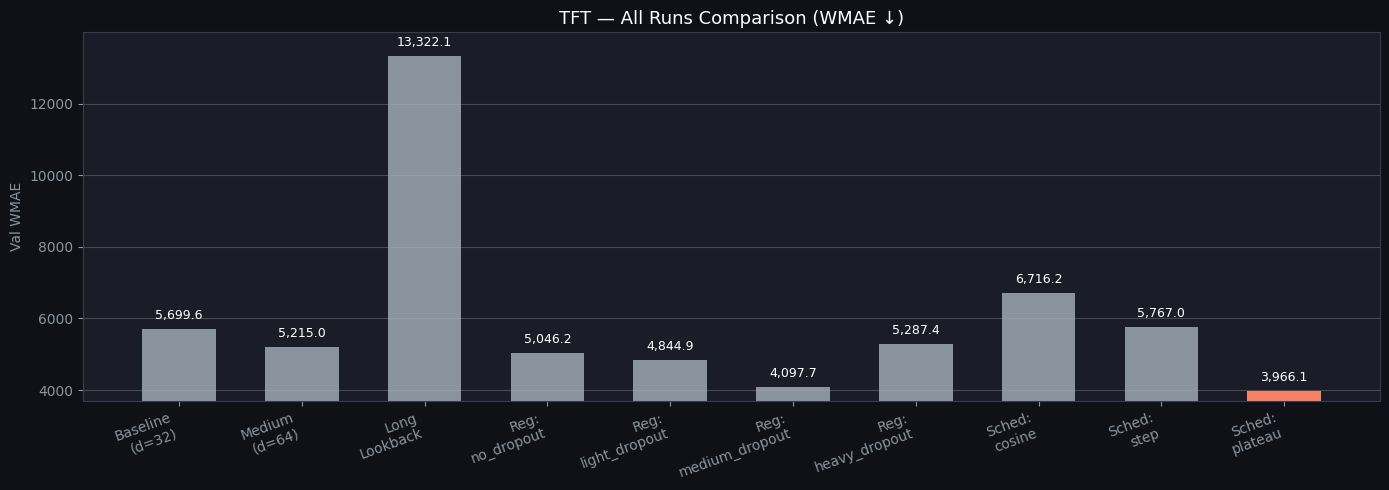


Best run: Sched: plateau
Best WMAE: 3,966.11


In [26]:
all_results = {
    'Baseline\n(d=32)':         baseline_wmae,
    'Medium\n(d=64)':           medium_wmae,
    'Long\nLookback':           long_wmae,
    **{f'Reg:\n{k}': v for k, v in dropout_results.items()},
    **{f'Sched:\n{k}': v for k, v in scheduler_results.items()},
}

names  = list(all_results.keys())
scores = list(all_results.values())
colors = ['#8b949e'] * len(names)
colors[scores.index(min(scores))] = '#f78166'

fig, ax = plt.subplots(figsize=(max(14, len(names)*1.2), 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

bars = ax.bar(names, scores, color=colors, edgecolor='none', width=0.6)
ax.bar_label(bars, labels=[f'{v:,.1f}' for v in scores],
             padding=5, color='white', fontsize=9)
ax.set_title('TFT — All Runs Comparison (WMAE ↓)', color='white', fontsize=13)
ax.set_ylabel('Val WMAE', color='#8b949e')
ax.set_ylim(min(scores)*0.93, max(scores)*1.05)
plt.xticks(rotation=20, ha='right', color='#8b949e')
ax.tick_params(colors='#8b949e')
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#3a3d4d')
plt.tight_layout()
plt.savefig("tft_all_runs.png", dpi=130, facecolor='#0f1117')
plt.show()

best_run   = names[scores.index(min(scores))]
best_score = min(scores)
print(f"\nBest run: {best_run.replace(chr(10),' ')}")
print(f"Best WMAE: {best_score:,.2f}")

In [ ]:
print("Retraining champion on full data")
full_train = pd.concat([train_scaled, val_scaled]).sort_values(['Store','Dept','Date'])
full_dataset = WalmartTFTDataset(full_train, seq_len=52, pred_len=12)
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)

champion_config = {
    **CONFIG_MEDIUM,
    'dropout':      DROPOUT_CONFIGS[best_dropout_cfg]['dropout'],
    'weight_decay': DROPOUT_CONFIGS[best_dropout_cfg]['weight_decay'],
    'epochs':       60,
    'patience':     20,
    'note':         'champion — retrained on full data',
}

champion_model = TemporalFusionTransformer(
    n_static=len(STATIC_FEATURES), n_time_varying=len(TIME_VARYING_KNOWN),
    seq_len=52, pred_len=12,
    d_model=champion_config['d_model'],
    n_heads=champion_config['n_heads'],
    n_lstm_layers=champion_config['n_lstm_layers'],
    dropout=champion_config['dropout'],
).to(device)

optimizer  = torch.optim.AdamW(champion_model.parameters(),
                                lr=champion_config['lr'], weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=champion_config['epochs'], eta_min=champion_config['lr']*0.01)
criterion  = nn.L1Loss()

wandb.init(entity="ml-final-projekt", project="walmart-forecasting", name="TFT_Champion_FullRetrain",
           config=champion_config, reinit=True)

for epoch in range(1, champion_config['epochs']+1):
    loss = train_epoch(champion_model, full_loader, optimizer, criterion, scheduler)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}/{champion_config['epochs']}  loss={loss:.4f}")
    wandb.log({'epoch': epoch, 'train_loss': loss})

wandb.finish()

torch.save({
    'model_state_dict':  champion_model.state_dict(),
    'config':            champion_config,
    'static_features':   STATIC_FEATURES,
    'tv_features':       TIME_VARYING_KNOWN,
    'best_val_wmae':     best_score,
}, "tft_champion.pt")

print(f"Champion saved. Best val WMAE: {best_score:,.2f}")

with mlflow.start_run(run_name="TFT_Champion"):
    mlflow.log_params(champion_config)
    mlflow.log_metric("best_val_wmae", best_score)
    mlflow.log_param("n_params", count_params(champion_model))
    mlflow.log_artifact("tft_champion.pt",          "model")
    mlflow.log_artifact("tft_all_runs.png",         "plots")
    mlflow.log_artifact("tft_attention_weights.png", "plots")
    mlflow.log_artifact("tft_vsn_weights.png",       "plots")
    print("Registered in MLflow")

Retraining champion on full data
Dataset built: 228,338 windows  (skipped 364 short series)


  Epoch 10/60  loss=11902.7914
  Epoch 20/60  loss=6864.1738


In [ ]:
print("Generating Kaggle submission")


champion_model.eval()

SEQ_LEN  = champion_config['seq_len']
PRED_LEN = champion_config['pred_len'] 

history_raw    = pd.concat([train_df, val_df]).sort_values(['Store', 'Dept', 'Date'])
history_scaled = pd.concat([train_scaled, val_scaled]).sort_values(['Store', 'Dept', 'Date'])

series_stats = {}
for (store, dept), grp in history_raw.groupby(['Store', 'Dept']):
    sales = grp['Weekly_Sales'].values.astype(np.float32)
    series_stats[(store, dept)] = (sales.mean(), sales.std() + 1e-8)

global_mean_sales = train_df['Weekly_Sales'].mean()

test_sorted = test.sort_values(['Store', 'Dept', 'Date'])

n_groups = test_sorted.groupby(['Store', 'Dept']).ngroups
for gi, ((store, dept), test_grp) in enumerate(test_sorted.groupby(['Store', 'Dept'])):
    test_grp = test_grp.sort_values('Date').reset_index(drop=True)
    dates    = test_grp['Date'].tolist()
    n_weeks  = len(dates)

    hist_grp        = history_raw[(history_raw['Store'] == store) & (history_raw['Dept'] == dept)].sort_values('Date')
    hist_scaled_grp = history_scaled[(history_scaled['Store'] == store) & (history_scaled['Dept'] == dept)].sort_values('Date')

    if len(hist_grp) == 0:
        for d in dates:
            predictions[(store, dept, d)] = global_mean_sales
        continue

    mu, std = series_stats[(store, dept)]

    sales_hist = hist_grp['Weekly_Sales'].values.astype(np.float32)
    cov_hist   = hist_scaled_grp[TIME_VARYING_KNOWN].values.astype(np.float32)

    if len(sales_hist) < SEQ_LEN:
        pad = SEQ_LEN - len(sales_hist)
        sales_hist = np.concatenate([np.full(pad, sales_hist[0], dtype=np.float32), sales_hist])
        cov_hist   = np.concatenate([np.repeat(cov_hist[:1], pad, axis=0), cov_hist], axis=0)

    cur_window_norm = ((sales_hist[-SEQ_LEN:] - mu) / std).astype(np.float32)
    cur_window_cov  = cov_hist[-SEQ_LEN:].astype(np.float32)

    static_vec = test_grp[STATIC_FEATURES].iloc[0].values.astype(np.float32)

    future_cov_grp = test_scaled[(test_scaled['Store'] == store) & (test_scaled['Dept'] == dept)].sort_values('Date')
    future_cov_all = future_cov_grp[TIME_VARYING_KNOWN].values.astype(np.float32)

    preds_all, ptr = [], 0
    while ptr < n_weeks:
        chunk_cov = future_cov_all[ptr: ptr + PRED_LEN]
        chunk_len = len(chunk_cov)
        if chunk_len < PRED_LEN:
            pad_n = PRED_LEN - chunk_len
            filler = chunk_cov[-1:] if chunk_len > 0 else cur_window_cov[-1:]
            chunk_cov = np.concatenate([chunk_cov, np.repeat(filler, pad_n, axis=0)], axis=0)

        seq_t    = torch.from_numpy(cur_window_norm).unsqueeze(0).to(device)
        static_t = torch.from_numpy(static_vec).unsqueeze(0).to(device)
        tv_t     = torch.from_numpy(cur_window_cov).unsqueeze(0).to(device)

        with torch.no_grad():
            pred, _, _ = champion_model(seq_t, static_t, tv_t)
        pred = np.clip(pred.cpu().numpy().flatten(), 0, None)

        preds_all.extend(pred[:chunk_len].tolist())

        new_norm = (pred - mu) / std
        cur_window_norm = np.concatenate([cur_window_norm, new_norm])[-SEQ_LEN:]
        cur_window_cov  = np.concatenate([cur_window_cov, chunk_cov])[-SEQ_LEN:]

        ptr += PRED_LEN

    for d, p in zip(dates, preds_all[:n_weeks]):
        predictions[(store, dept, d)] = p

    if (gi + 1) % 500 == 0:
        print(f"  {gi + 1:,}/{n_groups:,} series done")

print(f"\nPredictions generated for {len(predictions):,} (Store, Dept, Date) rows")

sub_ids, sub_preds = [], []
for row in test_sorted.itertuples(index=False):
    key = (row.Store, row.Dept, row.Date)
    pred = predictions.get(key, global_mean_sales)
    sub_ids.append(f"{int(row.Store)}_{int(row.Dept)}_{row.Date.strftime('%Y-%m-%d')}")
    sub_preds.append(pred)

submission = pd.DataFrame({'Id': sub_ids, 'Weekly_Sales': sub_preds})
submission.to_csv('submission.csv', index=False)

print(f"\nsubmission.csv saved  ({len(submission):,} rows)")
print(submission.head())
